# Urban Air Quality Analytics with Python

**BDA112 Assignment 2 | Group: 204_Spyder**

## Group members

* **Roma Sah** – MIT251869
* **Aashika Gharti** – MIT250470
* **Md Samiul Alam Rafi** – MIT250310

## Project overview

This project analyses a published OpenAQ-derived nitrogen dioxide (NO₂) dataset from monitoring stations in Antwerp, Paris and London. It explores pollution patterns and compares Linear Regression and Random Forest for predicting the next hourly Paris measurement. All concentrations are measured in µg/m³. The dataset is embedded in the notebook, so no separate CSV file or API key is required.

**Notebook review:** Roma Sah ran the notebook in VS Code on 14 September 2026 and reviewed the data-cleaning outputs, graphs and model scores with AI assistance. The genuine contributions of all group members and the supporting GitHub version history are recorded in Section 8.


## 1. Problem and tool choices

The aim was to predict the Paris NO₂ concentration one hour ahead using the most recent readings and calendar information. This is a regression problem as the result is numerical. Paris was chosen because it has more complete data than Antwerp and London.

Python supported the whole workflow. Pandas were used to import, clean and group data [1], NumPy handled numerical calculations [7], Matplotlib was used to create labelled charts [8], and scikit-learn provided regression models and evaluation metrics [4]–[6]. The Jupyter notebook in VS Code stored the code, explanations and outputs [3].

Python was more reproducible than manually repeating the analysis in a spreadsheet. A distributed platform was not needed since the data was so small. Linear regression was easy to understand and Random Forest could find more complex patterns but was less transparent.


## 2. Dataset acquisition and documentation
We used the data from the pandas project’s air_quality_no2.csv file on 4 September 2026. This is a published OpenAQ-derived teaching dataset containing NO₂ readings from BETR801 in Antwerp, FR04014 in Paris and London Westminster [1], [2]. It is a historical sample rather than a current download from the complete OpenAQ database.

The raw data has 1,035 rows and four columns. The **datetime** column records the time of observation while the **station_antwerp**, **station_paris** and **station_london **contain NO₂ concentrations in µg/m³. The blank cells indicate missing data.

A compressed version of the dataset is embedded in the notebook and checked with a SHA-256 value. Therefore, we do not need a separate CSV file or API key. The dataset does not contain timezone or original quality flag information, so we do not mark the times as UTC, and we need to be careful to interpret the hourly patterns.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import base64, gzip, hashlib, io, json, platform

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False})
print('Python:', platform.python_version())
print('pandas:', pd.__version__, '| NumPy:', np.__version__, '| scikit-learn:', sklearn.__version__)


Python: 3.14.6
pandas: 3.0.5 | NumPy: 2.5.1 | scikit-learn: 1.9.0


In [19]:
# Embedded source snapshot: no internet connection is needed to run the analysis.
DATA_B64 = 'H4sIAAAAAAACA31dW44tuY38n1V4AdUXIqmnNzNowP3RwLjbsC/g7c+RsiozIniqgfopROpNURSD4vnHrz9/+/n7P3/7+M/PX3/+/ucf//vrHz//+9u//3X//69f//37f+7//u/PP/7x5x//48XWL6X9Usbfiv+9lNffx8eHx49CUHxCrfxoH95+lA9b8kn9/KRu1MePkT9pXw28qqkf1gXuX3C3H+uDoPEFDX+VdC05b3i3Gy7wuiser4oVtnJ3q++uT4HtC466B28C37Pm5Ydl+GvmPiz2rGnl9YbLj76rYLhBac+l7xkz2z3X0gPgkeF71l71eu75PWvuPyKV9nvWXgVrhu9Zey3W/PAq8D1r0XfbCt+zFkGiMP9W7najpYpfMK6WSukEGX8NyjL81a7HVViXZD5y7nsrWEtTM0HOX6vWciPPqrV38LNqa1eu8IR5H2eUBC8o3fbsEvzIuo3XCCMENig9ZCtMkPVXwbo3OcPBIqFtVxi3ZfiZtbrHLQN7ZN3PnGvbA+St5J7fsxbztahhAj+yvue8yoKCrI8tc03ge9aqvVkxkPW5YRn3I+t1kqwvlHXfu4TaXSDrL8Q/ogjsMKGDK45HiMulenhKlsr5/i590kB5VRGmxXIeGR6kVxM84bAYGb5XrK7dNZka45njbbBQpx/dNgW+Z67GltQhcEDP87w/ch7tXekGuyRkAy+U8/palqWlHznfmrErPEFSy0fXrqGcr48m4wY5r68F7S6wQdvzoy2BHSr3jy5L4kHrTaWtgKz7Vj0JxvPkBbvAqNffwF9tW7k0ru2typ98rdrrrGx7x7z5pIFAF9YSG+5gCbQMP/K+lUjoAO+Vq2Nvpi7wvXJtbKmR0o+896Knwobv2WtbcYcMDPT6kVitPGDdnXfLhitrZuk5yLtvzdwE7qR6EzwA7nwqbPjR62VrZm170Zwr/Mj7dZ7JuB95j3QSbxi1RM9wQNuiPM1Q3udrzhNsfJ4NgR126szwrd/7ZaQ0tnr3J7d+36bjS95X/uReOdavG+rfQ+OBikATxrwyjNopj5l0uqXSoNMbHncbQmtzMoSWpjNUQbYEaiR2BHWwsKZsFkObfP4oIpGGNvk231LpBVOQZYrk2fjM3PAzQ7bPLYVRplx0iIE8vyTGjlA/sKM8nzuYwijPVYTGWX/PDN/6e1z627ctxZ9UMmnGu08e/b33FKtYR3ulq82wYbTL31Q+6R5Yq8ALzg7dao52+T71XdoGu/zc5BR2gCvf5DYcDBeB8Q66+D6y4XvW5m5a674nbR+qrsMaD9rZq7DRyaOSKXuE3bapo3U/wn5dXxU23kkKo7BbGpazicelA4S99lR54CXU38EOB2bJ8C3s206yrSl5agKMlc9PWv6kwfQs2eyBxkpLqiLQWJnJ3Ag0Vs7NQ+EFFyJVU6GK3KX0I+x+fCJD4EfYPZ3pAcKe7YUAWV96odooXmgsV90Bltvxhgf7cnRYE/qtx1ewtJcEg7Sf01ymlEzzlWGHgzcyHHCcqXlYWbVHho10N+/yitK+1UuCWdpXmveqpvlK52YFafc8uRWk/dX5nuHB3gHt4oTdbnIwVpb2SKUNDb2Z2iaXS0mTS9K+ZDNUVu1qPVdW7Z7hxv5DhfEC7yLQFeX9XCpc4Pn99X/DC+ykkabF0VG1ZK9VlvdI00LyXtPAwJTJwtTQ7XIkVmGDoyNEfTd0u0yyDRuY5cfxN9LJ0sCM2SeHHd+pftJ4aprAnYzsBA86unhZGsr6TOdCA1m/bPDKMMj6tsFD2n5kvST7q4GoF/XobDQILYKCXlcF1livvymMbvQlll1DOfd3MOp1TzMGcn5Ky7BAzt8th+NZGGlg4FrcB1aIpIBe7+rttY5WTE1r3dGKKcmC6KjXh3r/NnzL+tc9RzZxf2T98ukkuEEDug076vSRNnEHOW+edHoHORch7qjPy5tZA+tlJbXX0XpZ6aDuqM8jrXdHfb59SCypXc2XIShY6i2j/UEtTRcZL2qTdRTyI4far0WjYp3T2XhZqWdgqlflDTYsvg6tPFgdEzxQmY89MIUNnDhDrBPkRF/aMjIcIMF6ixgo4OdWp3CD0m/gzoeYwoOYrjSwyT0fAj/+xJZ8LcSJ7hs3iwNyoj2LKXKizd7BQe71BFe+XGnbDRZUTV3kRI8HnLcncqLu6rs35ET9mPja9iKVpG2T/6XLAUec6CZkEuxg07QMs5zzQTLZn+gZRl5U3Y3Ii4YlrQW8aD3oSGfsRFnPduxk34vql8m+l57hwST7EHiS9Z9KLz6pZGrAaClJoSMnevm9tDQ7EvgwQU70uK7YeCBO9Jj30nMyXFoaNxku6mucbKCr2YOc6PE5VR33onu2wresR7v4EpVY4EXPJ/2MX2bvlvn6aRG6sC7Aj24vw+aFYusF+AR40sMs9W05p0+++nJO5bZvQ3XJJ/6Q/22jPX8SaJ3HdpqnT+7L6tkG+6xNnzT6ZPtD0ycdvfPH0EifjMfHf+ZPTVPgUKNcm9pkjYBHjXJpS7XkgEu91JKl2xrwqfZlZ4qsAqd67QNL9iDwqvapubucasCt2icrsnJDDR0Knh1QwLGeMI9DZrrM7r13zmDOoFN3J43I0wYFvvW46E4sizZ076MvlibP7r2Pzkq347t3+cSfWs5+6/mTe3ZPT0NrceBgL4+iv/sEVrpdN1yaFwcu9nTXtninT2ilj35JDVWibF2vNw587LoqEb+5AyVr9YvkSp8M5A2uQAqTT6bsNMuf3Nto33ZeykcW2oGiPaquplPQgaY9+7U2ZYAcqNrjOq6hvhEHutY/ZSHP/72NrpC2tAEcaNvDNHloXJ0Ddev1kv2WPxno8fBkzzlRuEf7FIEX2dCknJwo3Hfi6sbBFgo7wJ0Pb0cK99y+K+5uJwp3G4sJRs9e56PPkcK1ro4BBwr3ChLryqw7ULiXCy3B4icKgTv4qVqG0ScqxoMjldtdnfSOVG6OqXSkcltVz6IjlXucUAl2clfruCFc4VPoGEZat+WuNQgskrgjR3q3niiOKvAAj0vP8HMp23FHIbP2yPpo6gJzpHdb1Sg1R3q3lcv0YNjBrTHTwBwvZeL1cKR3D0+eYPF6FIHRV2QZDow1y6e6O8p6cn04UrtHg9Nd2ZHajVAS05HarSf+ZQo8YVnkUuhI7Y6mFyNHaneceVf4uUpHOliQ2m0pnMCR2q3JXHKkdmsKIHSkdmOmrYDcbk1uU0dyN7IxgezusZN5KyC7G4lUcWR3I/kmHdndc2dIsINnc6VJpdAcPdeCQ9Fmhg1Un4niRHa3hbqMHNjd4zlpJ76wyCf3qvWuEciOzO7Y9ADx9Y7M7jCl8x2Z3T6VdHdkdsdKBhUyu8vUF+fI7K5xWQ0MG1Rec2lmKbVrdJUuuXSF81RNnuCwS4lu8eCwHYnucOJ2x7VsDE8K+umyYhRKP7b2JhjCLvcNq5nABtNyva8gGIOyJweeOHK7dVxXSYCR2z2PLhJsFPrHGwm53XDkuhx43VEv1TJz6UoOzgQ3UPlVhKmye9QyPCAcTK1x4nQTl+/I6baqQQaOnG5tGp7hyOlGtrwqy3nPlQd0raeeW6WAydDKG7sJtfRfBKl6ZffoOKYAwZMiAar2fNEprDDJeYikVrbVFzucHDndywUhK/bIuR3iksaNnO6Ju0uwMQ3nAjvs75rheJxLn9dZ1k4NZb0oS+HI6Ypxgnxuhp5QS9cuTTggV4YXGAa6eZDHrTXdDZDHPX5u7RbIdyJNHJncKzKrClxhpXR3IJd7KJfQtjvIWBcLG7nc4++qMi1gsxwR1LYXRSZVqdwL3UsSbOSlrjJuCSeuMjCwWdLDHkcut58AIIUNjFC11ZDL7Yk0ceBy97m370WqEYnLjXQn6xyfs8SkQS43vzVz5HJPQIQNgSc9LErwojgVawxD6OWJhFbYiPk0GRiFXkZqm57/hewU5HNPaBNvBSR0L5+ddo0f2Oic6/M/7RraLJZLY3yOPJFxpHTd34gDULrpxZQjpXvRPdI10OU9dQ0p3SsuSWFesQT7w6G3jNJLkTMxVb641ywf/cjp1mSb0xNXffnng1mu4Neejoyu7yi5BC+6gitshSJaE4yx4fI21+mVayQxH6zS38CVZakI3Mi4TnDn0i7wAKOjZ3jSgZDgxYpJYC9/WbmodD7piNH1N+Mmk0WFBRldW+kiNznsssuKIaNrLS0oMLpH6W3GOH3x3ELflW8PaqI0kc7dIWgJHX89sEkBkzxryOae+47CIOf7npdgCd4zgdkhnOAg65mVIrK5+VWOE5s7kyOc2NwUKOqT5bzkyifYRXpWTDZdZmqbwtA8w/aXPXdnBl1mjdzoFW6Ji13o6qCSF66qyvGF6xujA9nawzaaPkHwxW7FkuHGVrsJ3L9/ROD0wrUnV8viCB15JeD4wvVKuiCV0xV0iD5fmrUgwehCf1M6+M1eEbhyWgKZNdLnU7Y/vnDdJriCg8I8BeQ3NlqUVbmgpMkjoUYrKYJE8j0TGkTkYM1RWIuXhBqrQkGdPCCK3h6WiyCtH0U+oKBYBRu9VlC009NuRQeFvCo62eYVdIEqCVrhwHesdp75Cmpk6C9BMbRyslQGvmI9PDDZKIGvWK3quRH4ivUySWVUoLurmhFRNBLHte1JoTahbS/Sn3TqRGFT3DJsbOFI20SBvoExwlFcWWH8NKRk2Oj1LqmZMKaFPMMB/P5xY5jLF5UimBPcwJMm8mL8KCSj+FzbP7RrnE9Cyy56yy1lwULp6qII4wchnbVnIPl5HNVklwWSn9ddWNuu399HwzjfzMxwJ5uSDrSgt61Nj+Ogt62JzQ5jKRcbI4z1tzA+YfogJMH+/WPsQPKzF75R9l8KSnmXR7sXfLc9z0XbBb7bnvUdfDtX9h1/nGujNlChfcvw4zw0E6h/Dz3OwyrIhF3VP7S/C8wWFO6DGvLEARvjQvmZmknVqsG1dNCx49p0/S4dyQU3egsVMon0uK/k0oNLy2TSU1aiDC94MSxtO77+pSDRCzYKganStjoOZTWBANpmQKOuIbF/Yi0SjE9Zh1SOxP4V6ahwAOxIJ1xwBZ/mG7gx+TQERuu7ZZgVeOjAJsftKryYTigMW+E0S1KaYoYpkOOCnSvvAqPT0HJpdhqGzDnp8JIr75TEJGTOyVJZeWCTnmokeDEsXaN3ID3DeNubqXIKYFmy/Z0fO5Eh84KDLZWeYeNgKRMYvSkjw0H72xSu5IlNcHvs9PkRAnZ6vK/ooKj7Jugk86gLuiheSCYE7pdBt5oLNTgEShqRMVdn0jJcL8cVPM5w5SRt2nYjMTHteOdsNdq1wT4aF3iyx0G7tihDksLEcJI/8IKNn2YWgZHJLxkOsld53JVfrbYMGx3qfPQik9/2TTLBQdIwBcWMVyWhDd5Hd5YkofFnQtGFopJSOWkSuTEueEEoTpO1Rha/FU46csFG0VF85Fd1iYdWHt9Ff14wx26GrBa5UKoo8cquQhODgVh8S/ZEZVchxRFe8GKv2mJYDHGX0sT8lLQkzlGvKqV03QyBG0chtgwz62QhMCvxBAfG0NsWiSpf4GudmtBGPtQuKFsrig6yhFzQSTkvTdBFB19h1DBfZiTUKDNSE9QpSkBm+5HwnayNTX2k8eu5p8pkQehhcIzbBXfOmajwoI1t2vak+JsELzB5Z4IfAT+Bsgk2yimWYLxp5q5RZtMhEtxZiUeGkaWbrGg7u8PvaKwLCgp/qVKwEqGqaKPQ2yIov1JVdMBcBktu5yCsxrYNvcPeh6nUTF6UojUbp0+TaSSWxxMaFEjIR2HnOMMrMybBnGTKtGOd/TNd4LcRPRf0vFh3WaFHoBP0CHOG7Nu23L8vFe/CkfrJs1y+h+xdbun+fdrpTmmnP8ReRxY+Q+37Cvv3EMx8E4jT1qWSeF4WmTAk3jXBYX+XXloqN+dcSVo6OIWCTAVZGVPUKBHvjUNfuqSXjmSHD3b39bTkmspOp4UTFWvPHS/YegcenN1riX2ExPshTlLpIE/kAxHpXvn5R+f00leqgikwRwMRRHmphpSrD19eE/j99XAyUTMSOqC7xmbFZKIm14x3eTkyKJH0EXpBOV+d1Azuj/OsStAgN57MMGfAYOU7OaGRiYU32cenp+vUgCk+uuW9tMlmmuz7mAkmlqakykEZa7dAGfNxMdnnMUDeKHd07g4y6ycs3BR2SA+xMgxRUuVK8jbkiwopIDyhjRJEmKCdniIpOuhNSxN00oxo2UXeTBmVFUr4qahx/IWgHNEmvSLusbNML6Yeu0jtUse1yVw+Qp1tXeTTB+fZ75wuWkPlOqeLtuyQWKyjmxwAyKlHSefDYm+HiwmyOCfdekSbUkWHBOh1ThUdS115nCp6ctBG51TR8zLf5cjGVNEpuLFLmuip9gClibbgqJDOaaLPi9UETz7wXWCxRQbDRK8vdsBSmugz+CoDMycFWGXmhJ5JpdkJ2rR0w/ORfBKUJXrxq4XOSaKv40ar5vhgOrQpSbRmH+ycJNokl1znJNFXjJ+WdorS0+X0oKc/ZP1xkujKqRW7JImuaqBRkmhlkjsliR5fiRfpeMEc0Z/0vcKNsuib9q6DS3Fk+LnDT70JU67oduIXp8ALShfZxcbe654mjqJddRchD3lFVCgcHJCqlaOXqItECMculi3nj+78swxd8kcvflLVOX/0ETeirTh/dFOXJuWPPj5iLU2PLvO0OHqL8qQ+ot6S+UT5o9viJMWd80efFEQsy8RDjidXd6fc0YeKq0aHCXGQVbkZyhkdXfhsShl93pkqOmhCyJFAGaNjKxbeAMhA1vpmQsivJ75tyhh9nRMyX9/mWuycMDpR4ZwvuinPTvmiD5OW6u6cU0H7zU89qpbmaO6qbS9KYa6lJQZQe04xJFXON9fft9C2Kako3P0oXfSJIucpCc6Nvtjhzumi93IQBEkWT5DnEHVD3GOKXdE00RJ5wmmiazoBgjl2udRQmuhYHE7UJU10UdOV00Q3fnnTOU30sdb5gAjOy9Vy5UEPHRNcSYhT241yj5ssKOjwE7cZAg+ivEymxSap2VT5opgKcqxTomg/OW+kbZDxRL1SoujIahYpyDY5srdzougxOO6/c6LoMZO9gBTkqKTDkX48AVBTCvJ7eUUbePuZeOHM0LvLig6InXnT4ycJyn5MwAtJ9OOZTIHpRU7IUgD9eJjPkxRD2zenJO4Jxl9syKtFMq7GX2XnYJUDpnLEq8sBU9k5+AaelJ3ete313fuwLsmhV9JpleNI3sAOpsRKXQMZz6Ub//5cZNjYX6uwk0VNEP3GxQnnILi++0m8zgmh2VFDyaAz9Di8WXAy36jwomvHZJR+Yq4n1MiryDZR43TnJnuicbpzSx3jLNCmTcMNs4i51eiG2XPZQYkYEzz5lwFkqin8Tw3nxuF/JcPGO80Edt5p0rYHxwvTQdf5AY5lWB6ZNYGduTCF77Shfj1RmLLgnUOjaobRoSv+XsoBfXlsFR40sVNQjNlklx1lgT5et8ooJDqR4ChKAb3FsAvo+HMqCgalA9XxkAvFRWN3/aWWEPS7/M+d8z9Pjfmg9M+LX4d1yf4saUi7ZH+WH9vr77I/D4E5zMZlrj3ojvVASEe2nnwASEn2oWQAZX7u6x0Mol0+raEqn1RMf3oy/aRP2nPGn4f1JlYCUJbn2f/11ks/GbjNak3bDCjMejLMZHcN0JjnB3xbTYYrUJnH49/2rtG+kFVeM+zfs+OUGfroMoIqJSgniFyHhHQKlSVokBuGoEm/B0DQonc+CFFwa2XIvh0WPS3jHnpQDMwDIUu53agMPUZ2aCkHO9kZwgcQxlClSxxBDd4gNoY6PUclaNADXoImjKsytCifP0Lg7FsC0czzbLhToBpBQWGcD0S0Gt/yiSAaCjller8hp4dlC4fshV0lxhD/SDBBk4xjghaFxiJEkauLIX6ES5DTL/4ShOnKsULyapNsUM7Mc2UhSNwg/w/GQgp18HwAAA=='
csv_bytes = gzip.decompress(base64.b64decode(DATA_B64))
assert hashlib.sha256(csv_bytes).hexdigest() == '365ca31c9296ac200e73d357e16a3c1340f9ce6746c83bf81403046dcb374361'
raw = pd.read_csv(io.BytesIO(csv_bytes))
print('CSV SHA-256:', hashlib.sha256(csv_bytes).hexdigest())
print('Raw shape:', raw.shape)
print(raw.head().to_string(index=False))


CSV SHA-256: 365ca31c9296ac200e73d357e16a3c1340f9ce6746c83bf81403046dcb374361
Raw shape: (1035, 4)
           datetime  station_antwerp  station_paris  station_london
2019-05-07 02:00:00              NaN            NaN            23.0
2019-05-07 03:00:00             50.5           25.0            19.0
2019-05-07 04:00:00             45.0           27.7            19.0
2019-05-07 05:00:00              NaN           50.4            16.0
2019-05-07 06:00:00              NaN           61.9             NaN


## 3. Data quality and preprocessing

The data were checked for missing values, duplicates, invalid dates and incorrect measurements. No duplicates, invalid dates, negative values or invalid numeric values were found. Missing readings were 940 for Antwerp, 31 for Paris and 66 for London. The data were reindexed to a full hourly grid so each lag was for the right time. It was not possible to replace the missing values as it would produce artificial readings. The zero and IQR-flagged observations were kept, because they might be real pollution events.


In [20]:
stations = ['station_antwerp', 'station_paris', 'station_london']
print('Original missing cells:\n', raw.isna().sum().to_string())
print('Original types:\n', raw.dtypes.to_string())
exact_duplicates = int(raw.duplicated().sum())
df = raw.drop_duplicates().copy()
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
invalid_dates = int(df['datetime'].isna().sum())
df = df.dropna(subset=['datetime'])
assert not df['datetime'].duplicated().any(), 'Conflicting duplicate times need manual review.'
invalid_numeric = {}; negative = {}; zeros = {}
for col in stations:
    converted = pd.to_numeric(df[col], errors='coerce')
    invalid_numeric[col] = int((df[col].notna() & converted.isna()).sum())
    negative[col] = int((converted < 0).sum())
    zeros[col] = int((converted == 0).sum())
    df[col] = converted.where(np.isfinite(converted) & (converted >= 0))
df = df.set_index('datetime').sort_index()
full_index = pd.date_range(df.index.min(), df.index.max(), freq='h')
absent_hours = len(full_index.difference(df.index))
hourly = df.reindex(full_index)
hourly.index.name = 'datetime'
quality = pd.DataFrame({'observed': hourly.count(), 'missing_on_hourly_grid': hourly.isna().sum(),
                        'coverage_percent': hourly.notna().mean()*100, 'zero_values': pd.Series(zeros)})
print('Exact duplicates:', exact_duplicates, '| Invalid dates:', invalid_dates)
print('Invalid numeric strings:', invalid_numeric, '| Negative readings:', negative)
print('Range:', hourly.index.min(), 'to', hourly.index.max())
print('Absent timestamps:', absent_hours, '| Full hourly grid:', len(hourly))
print(quality.round(2).to_string())


Original missing cells:
 datetime             0
station_antwerp    940
station_paris       31
station_london      66
Original types:
 datetime               str
station_antwerp    float64
station_paris      float64
station_london     float64
Exact duplicates: 0 | Invalid dates: 0
Invalid numeric strings: {'station_antwerp': 0, 'station_paris': 0, 'station_london': 0} | Negative readings: {'station_antwerp': 0, 'station_paris': 0, 'station_london': 0}
Range: 2019-05-07 02:00:00 to 2019-06-21 02:00:00
Absent timestamps: 46 | Full hourly grid: 1081
                 observed  missing_on_hourly_grid  coverage_percent  zero_values
station_antwerp        95                     986              8.79            0
station_paris        1004                      77             92.88            7
station_london        969                     112             89.64           12


## 4. Exploratory data analysis

Paris had only 1,004 observed readings, compared to 969 for London and 95 for Antwerp. Its mean NO₂ concentration was 27.74 µg/m³ and its median was 24.15 µg/m³ with a maximum of 97 µg/m³. A higher mean than median and the long upper tail of the histogram indicate there were some unusually high readings. We used boxplots to compare the station distributions, but the study of Antwerp should be considered very carefully as it has limited data.

Daily averages were calculated only when at least 18 hourly readings were available. Paris had its highest hourly average at 09:00 (40.57 µg/m³) and its lowest at 16:00 (17.77 µg/m³). Friday had the highest weekday average (32.24 µg/m³) and Sunday had the lowest (24.07 µg/m³). These results show patterns in this short historical sample but do not establish their origin.


                  count   mean    std  min    25%    50%    75%   max
station_antwerp    95.0  25.78  12.68  7.5  16.75  23.00  34.50  74.5
station_paris    1004.0  27.74  15.29  0.0  16.50  24.15  35.92  97.0
station_london    969.0  24.78  11.21  0.0  19.00  25.00  31.00  97.0
IQR flags retained (descriptive only):
 station_antwerp     1
station_paris      32
station_london     30


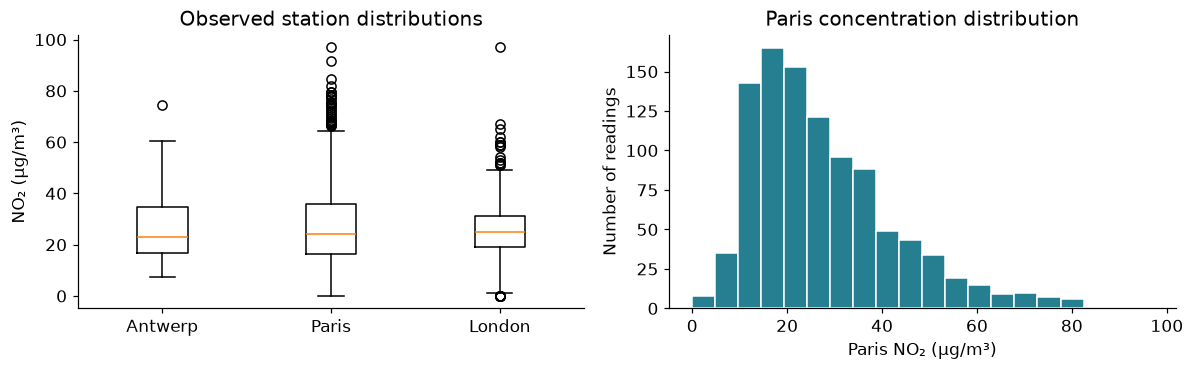

In [21]:
summary = hourly.describe().T
print(summary.round(2).to_string())
q1 = hourly.quantile(.25); q3 = hourly.quantile(.75); iqr = q3-q1
eda_outliers = ((hourly < q1-1.5*iqr) | (hourly > q3+1.5*iqr)).sum()
print('IQR flags retained (descriptive only):\n', eda_outliers.to_string())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].boxplot([hourly[c].dropna() for c in stations], tick_labels=['Antwerp','Paris','London'])
axes[0].set_ylabel('NO₂ (µg/m³)'); axes[0].set_title('Observed station distributions')
axes[1].hist(hourly.station_paris.dropna(), bins=20, color='#267F91', edgecolor='white')
axes[1].set(xlabel='Paris NO₂ (µg/m³)', ylabel='Number of readings', title='Paris concentration distribution')
fig.tight_layout(); plt.show()


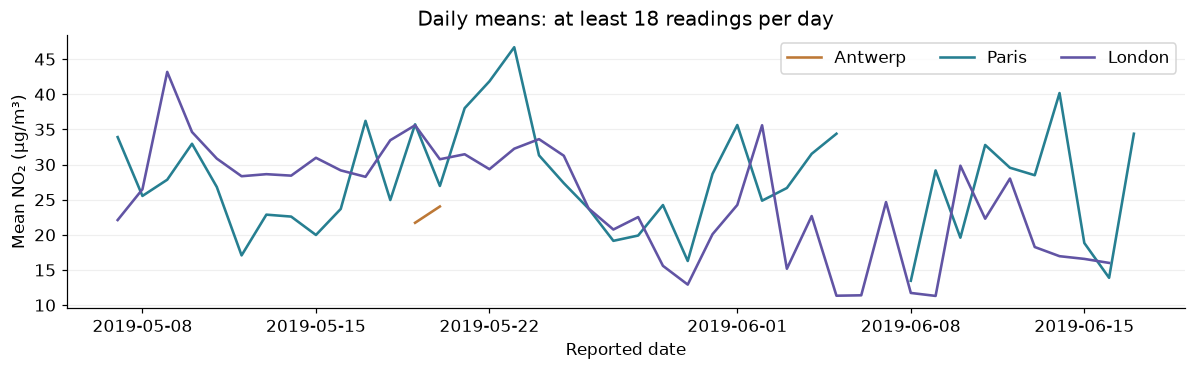

Paris mean and count by reported hour:
            mean  count
datetime              
0         35.40     43
1         34.29     42
2         31.68     42
3         27.43     42
4         25.96     42
5         25.23     38
6         27.26     38
7         35.53     38
8         40.10     42
9         40.57     43
10        36.46     43
11        30.08     43
12        23.66     43
13        20.46     42
14        18.57     42
15        17.96     43
16        17.77     43
17        18.85     42
18        21.27     42
19        23.59     42
20        24.20     42
21        26.64     42
22        29.71     42
23        33.24     43
Paris mean and count by weekday:
             mean  count
Monday     24.93    144
Tuesday    30.92    155
Wednesday  29.29    147
Thursday   27.87    145
Friday     32.24    139
Saturday   24.43    130
Sunday     24.07    144


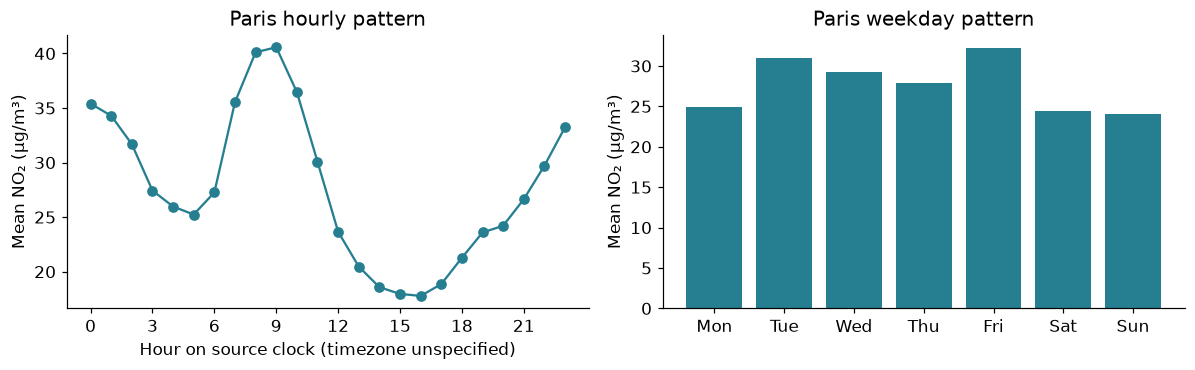

In [22]:
daily = hourly.resample('D').mean().where(hourly.resample('D').count() >= 18)
fig, ax = plt.subplots(figsize=(11, 3.5))
for c, label, color in zip(stations, ['Antwerp','Paris','London'], ['#BD7836','#267F91','#6154A4']):
    ax.plot(daily.index, daily[c], label=label, color=color, linewidth=1.7)
ax.set(ylabel='Mean NO₂ (µg/m³)', xlabel='Reported date', title='Daily means: at least 18 readings per day')
ax.legend(ncol=3); ax.grid(axis='y', alpha=.2); fig.tight_layout(); plt.show()
paris = hourly.station_paris
hour_profile = paris.groupby(paris.index.hour).agg(['mean','count'])
weekday_profile = paris.groupby(paris.index.dayofweek).agg(['mean','count'])
weekday_profile.index = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
print('Paris mean and count by reported hour:\n', hour_profile.round(2).to_string())
print('Paris mean and count by weekday:\n', weekday_profile.round(2).to_string())
fig, axes = plt.subplots(1,2,figsize=(11,3.5))
axes[0].plot(hour_profile.index, hour_profile['mean'], marker='o', color='#267F91')
axes[0].set(xlabel='Hour on source clock (timezone unspecified)', ylabel='Mean NO₂ (µg/m³)', title='Paris hourly pattern', xticks=range(0,24,3))
axes[1].bar(range(7), weekday_profile['mean'], color='#267F91')
axes[1].set(xticks=range(7), xticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], ylabel='Mean NO₂ (µg/m³)', title='Paris weekday pattern')
fig.tight_layout(); plt.show()


## 5. Building comparable prediction models

The Paris NO₂ reading at time **`t`** was predicted using readings from **`t−1`**, **`t−2`** and **`t−24`** hours. Hour-of-day and weekend features were also included. Sine and cosine transformations represented the repeating 24-hour cycle, so midnight was treated as close to 23:00.

The hourly timeline was divided chronologically into 60% training, 20% validation and 20% testing. After removing rows with incomplete targets or lag features, there were 595 training, 178 validation and 147 test observations. Random shuffling, future interpolation and same-hour target information were avoided to prevent data leakage. The validation set was used for model selection, while the test set was kept for final evaluation.

Linear regression was a simple and clear model [4]. Random Forest was employed to capture more complex relationships, with 300 trees, maximum depth 8, minimum leaf size 5 and random seed 42 included for comparison. A persistence baseline, which predicted the next reading as equal to the previous reading, was also included. This represents the rolling one-hour-ahead prediction as earlier actual readings became available over time.


In [23]:
model_data = pd.DataFrame({'target': paris})
for lag in [1,2,24]:
    model_data[f'lag_{lag}'] = paris.shift(lag)
model_data['hour_sin'] = np.sin(2*np.pi*model_data.index.hour/24)
model_data['hour_cos'] = np.cos(2*np.pi*model_data.index.hour/24)
model_data['weekend'] = (model_data.index.dayofweek >= 5).astype(int)
features = ['lag_1','lag_2','lag_24','hour_sin','hour_cos','weekend']
cut1 = hourly.index[int(.60*len(hourly))]
cut2 = hourly.index[int(.80*len(hourly))]
complete = model_data.dropna().copy()
train = complete.loc[complete.index < cut1]
valid = complete.loc[(complete.index >= cut1) & (complete.index < cut2)]
test = complete.loc[complete.index >= cut2]
assert train.index.max() < valid.index.min() < test.index.min()
assert model_data.loc[hourly.index[24], 'lag_24'] == paris.iloc[0] or pd.isna(paris.iloc[0])
print('Rows excluded for missing target/lags:', len(model_data)-len(complete))
for name, part in [('Train',train),('Validation',valid),('Test',test)]:
    print(name, len(part), 'rows:', part.index.min(), 'to', part.index.max())
tq1,tq3 = train.target.quantile([.25,.75]); tiqr=tq3-tq1
print('Training IQR bounds:', tq1-1.5*tiqr, tq3+1.5*tiqr)
print('Training outliers retained:', int(((train.target<tq1-1.5*tiqr)|(train.target>tq3+1.5*tiqr)).sum()))
print('Training-only feature correlations:\n', train[['target']+features].corr()['target'].round(3).to_string())


Rows excluded for missing target/lags: 161
Train 595 rows: 2019-05-08 03:00:00 to 2019-06-03 01:00:00
Validation 178 rows: 2019-06-03 02:00:00 to 2019-06-12 01:00:00
Test 147 rows: 2019-06-12 02:00:00 to 2019-06-19 00:00:00
Training IQR bounds: -8.800000000000004 60.00000000000001
Training outliers retained: 29
Training-only feature correlations:
 target      1.000
lag_1       0.848
lag_2       0.663
lag_24      0.333
hour_sin    0.220
hour_cos    0.057
weekend    -0.035


In [24]:
def metrics(actual, predicted):
    return {'MAE': mean_absolute_error(actual,predicted),
            'RMSE': np.sqrt(mean_squared_error(actual,predicted)),
            'R2': r2_score(actual,predicted)}

def make_models():
    return {'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(n_estimators=300,max_depth=8,
                         min_samples_leaf=5,random_state=42,n_jobs=1)}

models = make_models()
validation_scores = {'Persistence': metrics(valid.target, valid.lag_1)}
for name, model in models.items():
    model.fit(train[features], train.target)
    validation_scores[name] = metrics(valid.target,model.predict(valid[features]))
validation_table = pd.DataFrame(validation_scores).T
selected_name = validation_table.loc[list(models), 'MAE'].idxmin()
print('Validation scores:\n',validation_table.round(4).to_string())
print('Model selected using validation MAE:',selected_name)


Validation scores:
                       MAE    RMSE      R2
Persistence        5.2191  6.9411  0.7294
Linear Regression  4.8921  6.4813  0.7641
Random Forest      4.5533  6.3535  0.7733
Model selected using validation MAE: Random Forest


## 6. Evaluation on the later test period

Three regression metrics were used. The mean absolute error (MAE) shows the average prediction error in µg/m³ and can be easily understood. The root mean squared error (RMSE) gives more weight to large errors, while R² measures how much variation the model explains compared with predicting the mean. Lower MAE and RMSE and a higher R² indicate better performance. Precision and recall were not used because they are classification metrics and the target was continuous [6].

After validation, both models were refitted using the combined 773 training and validation observations. They were then evaluated once on the same 147 later test observations and compared with the persistence baseline. The model selected using validation MAE did not change after seeing test results, which reduces the risk of selecting a model that just performs well on the test data.


Final test scores:
                       MAE    RMSE      R2
Persistence        5.6844  8.2995  0.7869
Linear Regression  5.1162  7.3003  0.8351
Random Forest      4.9190  7.4858  0.8266
Refit training scores (diagnostic only):
                       MAE    RMSE      R2
Linear Regression  5.1906  7.5071  0.7428
Random Forest      3.7321  5.6901  0.8523
Selected model test MAE improvement against persistence: 13.46%
Negative predictions: {'Persistence': 0, 'Linear Regression': 1, 'Random Forest': 0}


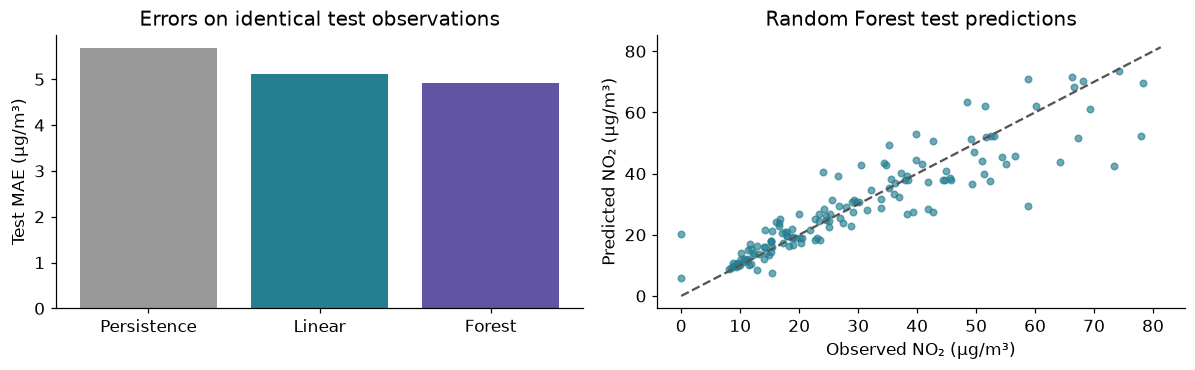

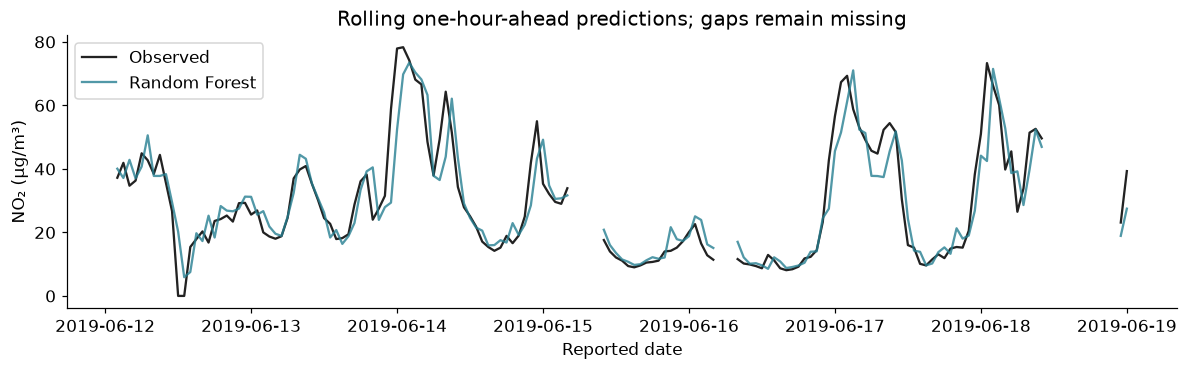

In [25]:
train_valid = pd.concat([train,valid])
final_models = make_models()
predictions = pd.DataFrame({'actual':test.target,'Persistence':test.lag_1})
test_scores = {'Persistence':metrics(test.target,test.lag_1)}
training_scores = {}
for name,model in final_models.items():
    model.fit(train_valid[features],train_valid.target)
    predictions[name] = model.predict(test[features])
    test_scores[name] = metrics(test.target,predictions[name])
    training_scores[name] = metrics(train_valid.target,model.predict(train_valid[features]))
test_table = pd.DataFrame(test_scores).T
print('Final test scores:\n',test_table.round(4).to_string())
print('Refit training scores (diagnostic only):\n',pd.DataFrame(training_scores).T.round(4).to_string())
improvement = 100*(test_table.loc['Persistence','MAE']-test_table.loc[selected_name,'MAE'])/test_table.loc['Persistence','MAE']
print(f'Selected model test MAE improvement against persistence: {improvement:.2f}%')
print('Negative predictions:', (predictions.drop(columns='actual')<0).sum().to_dict())
fig,axes = plt.subplots(1,2,figsize=(11,3.5))
axes[0].bar(['Persistence','Linear','Forest'],test_table.MAE,color=['#999999','#267F91','#6154A4'])
axes[0].set(ylabel='Test MAE (µg/m³)',title='Errors on identical test observations')
axes[1].scatter(test.target,predictions[selected_name],alpha=.65,s=18,color='#267F91')
limit=max(test.target.max(),predictions[selected_name].max())+3
axes[1].plot([0,limit],[0,limit],color='#555555',linestyle='--')
axes[1].set(xlabel='Observed NO₂ (µg/m³)',ylabel='Predicted NO₂ (µg/m³)',title=selected_name+' test predictions')
fig.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(11,3.5))
show=predictions[['actual',selected_name]].reindex(pd.date_range(test.index.min(),test.index.max(),freq='h'))
ax.plot(show.index,show.actual,label='Observed',color='#222222')
ax.plot(show.index,show[selected_name],label=selected_name,color='#267F91',alpha=.8)
ax.set(xlabel='Reported date',ylabel='NO₂ (µg/m³)',title='Rolling one-hour-ahead predictions; gaps remain missing')
ax.legend();fig.tight_layout();plt.show()


## 7. Interpretation, limitations and recommendations

**Main findings:** Our main results are that Paris recorded an average NO₂ concentration of 27.74 µg/m³ and the highest hourly average was at 09:00. Friday had the highest weekday average. Yet these patterns are not indicative of traffic, weather or other reasons for the changes.

**Model decision:** The lowest validation MAE of Random Forest was 4.5533 compared to 4.8921 for Linear Regression and 5.2191 for persistence. We therefore selected Random Forest before analyzing the test results. On the 147 test observations, it achieved a MAE of 4.9190 µg/m³, RMSE of 7.4858 µg/m³ and R² of 0.8266. Its MAE was 13.46% lower than the persistence baseline, so it was better at predicting one hour ahead. Linear Regression achieved a better test RMSE of 7.3003 and R² of 0.8351. Therefore, Random Forest was best for the chosen MAE measure but was not superior on all metrics.

**Model and data limitations:** Random Forest’s training MAE of 3.7321 was lower than its test MAE, which indicates that the model was overfitting or the pollution pattern changed over time. Linear regression also produced one negative prediction, which is physically impossible for NO₂. The dataset was small, historical and only had three monitoring stations. Antwerp had very low coverage, which could have masked important events. The data was also incomplete for timezone details, quality flags, weather, traffic conditions, and emissions information. The last usable test observation was 19 June at 00:00 because later rows did not contain all the required lag values.

**Recommendations:** This analysis should be viewed more as a classroom prototype, as opposed to an operational forecasting system. Future work should use a longer, quality-checked dataset with confirmed timezones and several seasons. Weather and traffic variables could be added only when they would be available at prediction time. The models should also be tested across several later periods and monitoring stations. Missing readings, unusual pollution events and model errors should be reviewed regularly, and performance continually compared against the persistence baseline.


## 8. Collaboration and milestones

The group used GitHub to keep a record of genuine reviews and file updates. Each member reviewed a different part of the project and committed their work using their own GitHub account.

| Actual date | Member and student ID        | Milestone and work completed                                                                                                                                                           | Evidence/version link                                             | Reviewer        |
| ----------- | ---------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------- | --------------- |
|  Sep 25, 2026     | Aashika Gharti – MIT250470| **Dataset and preprocessing:** Reviewed the dataset source and data dictionary. Checked missing values, duplicates, invalid values and hourly reindexing. Reviewed Sections 1–3.       | GitHub commit: `Review dataset documentation and preprocessing`   | Roma Sah |
| Sep 26, 2026     | Roma Sah– MIT251869 | **Exploratory data analysis:** Checked the summary statistics, boxplots, histogram, daily trends and Paris hourly and weekday results. Reviewed Section 4.                             | GitHub commit: `Review EDA charts and findings`                   | Roma Sah|
| Sep 21, 2026     | Roma Sah– MIT251869 | **Modelling and evaluation:** Checked feature creation, chronological splitting, Linear Regression, Random Forest, persistence baseline and evaluation metrics. Reviewed Sections 5–7. | GitHub commit: `Verify model scores and recommendations`          | Roma sah |
| Sep 26, 2026    | Roma Sah- MIT251869   | **Final review:** Ran the notebook from beginning to end, checked the outputs and reviewed the final report before submission.                                                         | GitHub commit: `Final notebook and report checked for submission` | All members     |

**GitHub repository:**
https://github.com/romasah62414/BDA112-Assignment-2-Air-Quality

